<a href="https://colab.research.google.com/github/Saransh-Basu-01/50-Ml-Projects-to-understand-LLMs/blob/main/Project_7_Translating_between_Tokenizers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Part_1:Number of Tokens

## Task_1:
- Find the number of tokens in each tokenizer, using the relevant at
tribute in the tokenizer instances. You already know from previous
projects that the GPT-2 tokenizer has an attribute vocab_size; the
question is whether the GPT-4 tokenizer has that same attribute with
the same name. You can use dir(obj) to see a list of all attributes
of variable obj

In [2]:
import tiktoken
tokenizer_4 = tiktoken.get_encoding('cl100k_base')

In [3]:
from transformers import AutoTokenizer
tokenizer_2 = AutoTokenizer.from_pretrained('gpt2')

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

In [4]:
dir(tokenizer_4)

['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__setstate__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_core_bpe',
 '_encode_bytes',
 '_encode_only_native_bpe',
 '_encode_single_piece',
 '_mergeable_ranks',
 '_pat_str',
 '_special_token_values',
 '_special_tokens',
 'decode',
 'decode_batch',
 'decode_bytes',
 'decode_bytes_batch',
 'decode_single_token_bytes',
 'decode_tokens_bytes',
 'decode_with_offsets',
 'encode',
 'encode_batch',
 'encode_ordinary',
 'encode_ordinary_batch',
 'encode_single_token',
 'encode_to_numpy',
 'encode_with_unstable',
 'eot_token',
 'is_special_token',
 'max_token_value',
 'n_vocab',
 'name',
 'special_tokens_set',
 'token_byte_values']

In [5]:
print(f'GPT-4 tokenizer has {tokenizer_4.n_vocab:7,} tokens.')
print(f'GPT-2 tokenizer has {tokenizer_2.vocab_size:7,} tokens.')

GPT-4 tokenizer has 100,277 tokens.
GPT-2 tokenizer has  50,257 tokens.


# Part_2:Token Byte Length Distribution

## Task_2:
- Count the number of bytes in all tokens, and generate the histograms
shown in Figure 2.19. Use the NumPy function bincounts instead
of a histogram.

In [6]:

# using initialization and a for-loop
lengths_2 = np.zeros(tokenizer_2.vocab_size,dtype=int)
for t in range(tokenizer_2.vocab_size):
  lengths_2[t] = len(tokenizer_2.decode(t).encode('utf-8'))

# using list-comprehension

lengths_2 = [ len(tokenizer_2.decode(t).encode('utf-8')) for t in range(tokenizer_2.vocab_size) ]

In [7]:

# initialize
lengths_4 = np.zeros(tokenizer_4.n_vocab,dtype=int)

# get the lengths
for t in range(tokenizer_4.n_vocab):

  # some token IDs cannot be decoded in isolation
  try:
    lengths_4[t] = len(tokenizer_4.decode([t]).encode('utf-8'))
  except:
    lengths_4[t] = -1

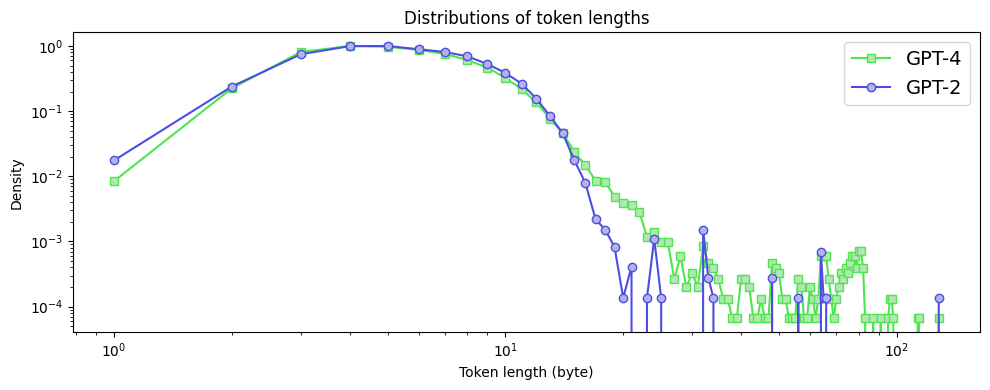

In [8]:

# bin counts for lengths
bincounts_2 = np.bincount(lengths_2)
bincounts_4 = np.bincount(lengths_4[lengths_4>-1])

# note: first element in np.bincount output is for count=0, which we can ignore

# plot
plt.figure(figsize=(10,4))
plt.plot(range(1,max(lengths_4)+1),bincounts_4[1:]/bincounts_4.max(),'s-',color=[.3,.9,.3],markerfacecolor=[.7,.9,.7],label='GPT-4')
plt.plot(range(1,max(lengths_2)+1),bincounts_2[1:]/bincounts_2.max(),'o-',color=[.3,.3,.9],markerfacecolor=[.7,.7,.9],label='GPT-2')

plt.legend(fontsize=14)
plt.gca().set(xlabel='Token length (byte)',ylabel='Density',
              title='Distributions of token lengths',yscale='log',xscale='log')

plt.tight_layout()
plt.show()


# Part_3:Text Token Lengths

## Task_1:
- In a for-loop over the books, import each book, tokenize twice to
obtain a list of GPT-2 tokens and a list of GPT-4 tokens, count and
store the total number of tokens in the book, and count and store
the average number of bytes in all the tokens in the book.
Visualize the results in two scatter plots as in Figure 2.20.

In [14]:
baseurl = 'https://www.gutenberg.org/cache/epub/'

bookurls = [
    # code       title
    ['84',    'Frankenstein'    ],
    ['64317', 'GreatGatsby'     ],
    ['11',    'AliceWonderland' ],
    ['1513',  'RomeoJuliet'     ],
    ['76',    'HuckFinn'        ],
    ['219',   'HeartDarkness'   ],
    ['2591',  'GrimmsTales'     ],
    ['2148',  'EdgarAllenPoe'   ],
    ['36',    'WarOfTheWorlds'  ],
    ['829',   'GulliversTravels']
]
import requests

In [15]:
# initialize
tokens_2 = np.zeros(len(bookurls))
tokens_4 = np.zeros(len(bookurls))
token_lens_2 = np.zeros(len(bookurls))
token_lens_4 = np.zeros(len(bookurls))


# loop over books
for i,(code,title) in enumerate(bookurls):

  # get the text
  fullurl = baseurl + code + '/pg' + code + '.txt'
  text = requests.get(fullurl).text

  # tokenize the text
  gpt2_toks = tokenizer_2.encode(text)
  gpt4_toks = tokenizer_4.encode(text)

  # count the numbers of tokens
  tokens_2[i] = len( gpt2_toks )
  tokens_4[i] = len( gpt4_toks )

  # count the average lengths of the tokens
  token_lens_2[i] = np.mean([len(tokenizer_2.decode(t).encode('utf-8'))   for t in gpt2_toks])
  token_lens_4[i] = np.mean([len(tokenizer_4.decode([t]).encode('utf-8')) for t in gpt4_toks])


[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (114213 > 1024). Running this sequence through the model will result in indexing errors


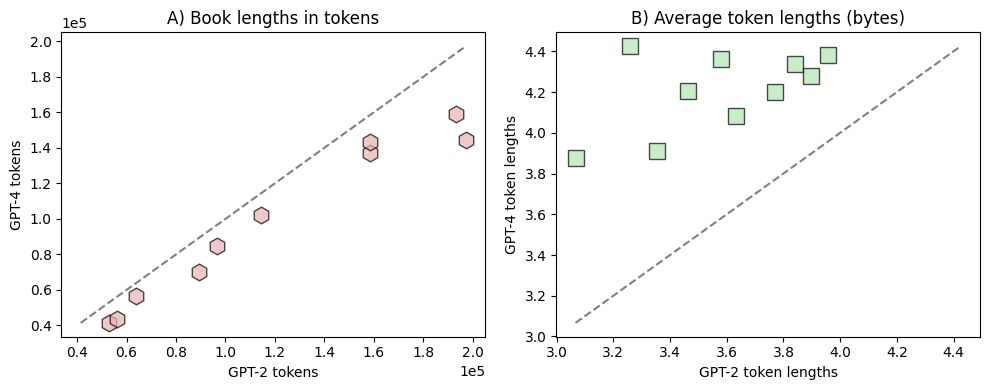

In [16]:
# setup the figure
_,axs = plt.subplots(1,2,figsize=(10,4))

### left panel: token counts

# the scatter plot
axs[0].plot(tokens_2,tokens_4,'kh',markerfacecolor=[.9,.7,.7,.7],markersize=12)

# line of unity
minlength = np.min([np.min(tokens_2),np.min(tokens_4)])
maxlength = np.max([np.max(tokens_2),np.max(tokens_4)])
axs[0].plot([minlength,maxlength],[minlength,maxlength],'--',color=[.5,.5,.5])

# stylize
axs[0].set(xlabel='GPT-2 tokens',ylabel='GPT-4 tokens',title='A) Book lengths in tokens')
axs[0].ticklabel_format(style='scientific',axis='both',scilimits=(0,0))


### right panel: token lengths
axs[1].plot(token_lens_2,token_lens_4,'ks',markerfacecolor=[.7,.9,.7,.7],markersize=12)

minlength = np.min([np.min(token_lens_2),np.min(token_lens_4)])
maxlength = np.max([np.max(token_lens_2),np.max(token_lens_4)])
axs[1].plot([minlength,maxlength],[minlength,maxlength],'--',color=[.5,.5,.5])

# stylize
axs[1].set(xlabel='GPT-2 token lengths',ylabel='GPT-4 token lengths',title='B) Average token lengths (bytes)')


plt.tight_layout()
plt.show()

# Part_4:Translator Funtion

## Task_1:
- Write two Python functions that take in a token integer sequence in
one tokenizer (e.g., GPT-4) and return a token integer sequence in
another tokenizer (GPT-2). Test your functions using the following
text (preserve the capitalization):
Canadian winters are kept WArM bY the friendliness of THE
PEOPLE

In [17]:


def gpt2_to_4(toks):
  newtxt  = tokenizer_2.decode(toks)
  newtoks = tokenizer_4.encode(newtxt)
  return newtoks


def gpt4_to_2(toks):
  newtxt=tokenizer_4.decode(toks)
  newtoks=tokenizer_2.encode(newtxt)
  return newtoks

In [18]:

text = 'Canadian winters are kept WArM bY the friendliness of THE PEOPLE.'
print('Original text:\n ',text,'\n')

# tokenize
toks_2 = tokenizer_2.encode(text)
toks_4 = tokenizer_4.encode(text)

# print the original tokens
print('GPT-2 tokens:\n ',toks_2)
print('GPT-4 tokens:\n ',toks_4,'\n')

# show that the decoding reconstructs the original text
print('GPT-2 reconstruction:\n ',tokenizer_2.decode(toks_2))
print('GPT-4 reconstruction:\n ',tokenizer_4.decode(toks_4),'\n')

# and finally, translate between tokenizers
print('GPT-2 to GPT-4 translation:\n ',tokenizer_4.decode(gpt2_to_4(toks_2)))
print('GPT-4 to GPT-2 translation:\n ',tokenizer_2.decode(gpt4_to_2(toks_4)))

Original text:
  Canadian winters are kept WArM bY the friendliness of THE PEOPLE. 

GPT-2 tokens:
  [28203, 45764, 389, 4030, 370, 3163, 44, 275, 56, 262, 1545, 26061, 286, 3336, 36388, 13]
GPT-4 tokens:
  [60674, 86082, 527, 8774, 468, 7098, 44, 293, 56, 279, 4333, 49958, 315, 3247, 67825, 13] 

GPT-2 reconstruction:
  Canadian winters are kept WArM bY the friendliness of THE PEOPLE.
GPT-4 reconstruction:
  Canadian winters are kept WArM bY the friendliness of THE PEOPLE. 

GPT-2 to GPT-4 translation:
  Canadian winters are kept WArM bY the friendliness of THE PEOPLE.
GPT-4 to GPT-2 translation:
  Canadian winters are kept WArM bY the friendliness of THE PEOPLE.


# Part_5:BERT vs GPT-2 Tokenizer

## Task_1:
- Make a copy of the GPT-2 vs. GPT-4 notebook file (Parts 1-4)
to modify for Part 5

In [19]:
from transformers import BertTokenizer
tokenizer_B = BertTokenizer.from_pretrained('bert-base-uncased')

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [20]:
from transformers import AutoTokenizer
tokenizer_G = AutoTokenizer.from_pretrained('gpt2')

In [21]:
text = 'Peanut and strawberry'
tokens = tokenizer_B.encode(text)


print(f'Original text:\n {text}\n')
print(f'Token sequence:\n {tokens}\n')

for t in tokens:
  print(f'Token index {t:6} is "{tokenizer_B.decode(t)}"')

Original text:
 Peanut and strawberry

Token sequence:
 [101, 21443, 1998, 16876, 102]

Token index    101 is "[CLS]"
Token index  21443 is "peanut"
Token index   1998 is "and"
Token index  16876 is "strawberry"
Token index    102 is "[SEP]"


## Task_2
- Find at least two ways to obtain BERT tokens without the preceding
and postceding special tokens. Slicing and toggling them off during
encoding are two options

In [22]:

# ignoring by slicing
print(tokenizer_B.decode(tokens[1:-1]))

# ignoring by input argument
tokens = tokenizer_B.encode(text,add_special_tokens=False)
print(tokenizer_B.decode(tokens))

peanut and strawberry
peanut and strawberry


In [23]:

print(f'BERT tokenizer has {tokenizer_B.vocab_size:,} tokens.')
print(f'GPT2 tokenizer has {tokenizer_G.vocab_size:,} tokens.')


BERT tokenizer has 30,522 tokens.
GPT2 tokenizer has 50,257 tokens.


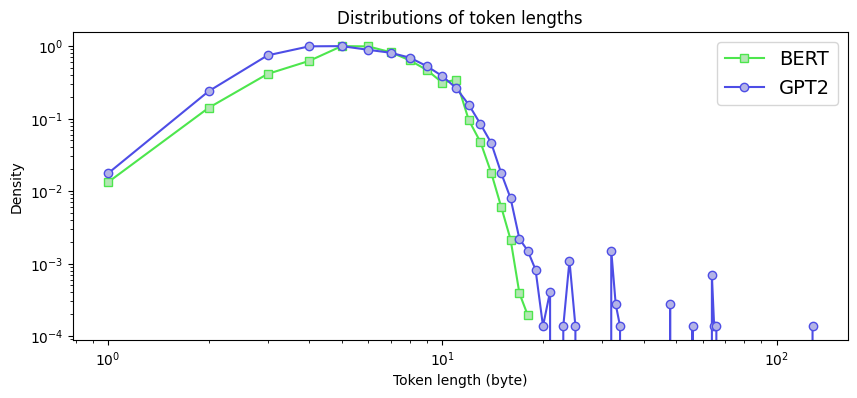

In [25]:
# initialize
lengths_B = np.zeros(tokenizer_B.vocab_size,dtype=int)

# get all the lengths
for t in range(tokenizer_B.vocab_size):
  lengths_B[t] = len(tokenizer_B.decode(t).encode('utf-8'))
# initialize
lengths_G = np.zeros(tokenizer_G.vocab_size,dtype=int)

# get all the lengths
for t in range(tokenizer_G.vocab_size):
  lengths_G[t] = len(tokenizer_G.decode(t).encode('utf-8'))

bincounts_B = np.bincount(lengths_B)
bincounts_G = np.bincount(lengths_G)

# note: first element in np.bincount output is for count=0, which we can ignore

# plot
plt.figure(figsize=(10,4))
plt.plot(range(1,max(lengths_B)+1),bincounts_B[1:]/bincounts_B.max(),'s-',color=[.3,.9,.3],markerfacecolor=[.7,.9,.7],label='BERT')
plt.plot(range(1,max(lengths_G)+1),bincounts_G[1:]/bincounts_G.max(),'o-',color=[.3,.3,.9],markerfacecolor=[.7,.7,.9],label='GPT2')

plt.legend(fontsize=14)
plt.gca().set(xlabel='Token length (byte)',ylabel='Density',
              title='Distributions of token lengths',yscale='log',xscale='log')

plt.show()

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (96279 > 512). Running this sequence through the model will result in indexing errors
[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (114213 > 1024). Running this sequence through the model will result in indexing errors


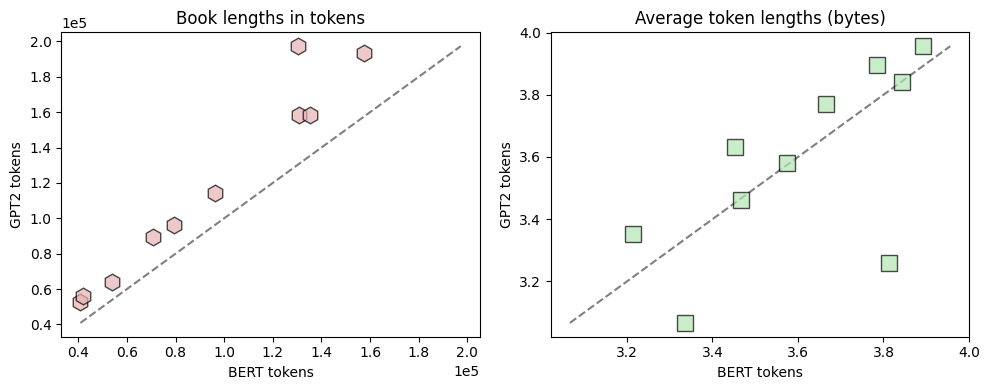

In [26]:
baseurl = 'https://www.gutenberg.org/cache/epub/'

bookurls = [
    # code       title
    ['84',    'Frankenstein'    ],
    ['64317', 'GreatGatsby'     ],
    ['11',    'AliceWonderland' ],
    ['1513',  'RomeoJuliet'     ],
    ['76',    'HuckFinn'        ],
    ['219',   'HeartDarkness'   ],
    ['2591',  'GrimmsTales'     ],
    ['2148',  'EdgarAllenPoe'   ],
    ['36',    'WarOfTheWorlds'  ],
    ['829',   'GulliversTravels']
]
tokens_B = np.zeros(len(bookurls))
tokens_G = np.zeros(len(bookurls))
token_lens_B = np.zeros(len(bookurls))
token_lens_G = np.zeros(len(bookurls))


# loop over books
for i,(code,title) in enumerate(bookurls):

  # get the text
  fullurl = baseurl + code + '/pg' + code + '.txt'
  text = requests.get(fullurl).text

  # tokenize the text
  brt_toks = tokenizer_B.encode(text,add_special_tokens=False)
  gpt_toks = tokenizer_G.encode(text)

  # count the numbers of tokens
  tokens_B[i] = len( brt_toks )
  tokens_G[i] = len( gpt_toks )

  # count the average lengths of the tokens
  token_lens_B[i] = np.mean([len(tokenizer_B.decode(t).encode('utf-8')) for t in brt_toks])
  token_lens_G[i] = np.mean([len(tokenizer_G.decode(t).encode('utf-8')) for t in gpt_toks])

_,axs = plt.subplots(1,2,figsize=(10,4))

### left panel: token counts

# the scatter plot
axs[0].plot(tokens_B,tokens_G,'kh',markerfacecolor=[.9,.7,.7,.7],markersize=12)

# line of unity
minlength = np.min([np.min(tokens_B),np.min(tokens_G)])
maxlength = np.max([np.max(tokens_B),np.max(tokens_G)])
axs[0].plot([minlength,maxlength],[minlength,maxlength],'--',color=[.5,.5,.5])

# stylize
axs[0].set(xlabel='BERT tokens',ylabel='GPT2 tokens',title='Book lengths in tokens')
axs[0].ticklabel_format(style='scientific',axis='both',scilimits=(0,0))


### right panel: token lengths
axs[1].plot(token_lens_B,token_lens_G,'ks',markerfacecolor=[.7,.9,.7,.7],markersize=12)

minlength = np.min([np.min(token_lens_B),np.min(token_lens_G)])
maxlength = np.max([np.max(token_lens_B),np.max(token_lens_G)])
axs[1].plot([minlength,maxlength],[minlength,maxlength],
            '--',zorder=-10,color=[.5,.5,.5])

# stylize
axs[1].set(xlabel='BERT tokens',ylabel='GPT2 tokens',title='Average token lengths (bytes)')


plt.tight_layout()
plt.show()


In [27]:
def GPT_to_BERT(toks):
  newtxt  = tokenizer_G.decode(toks)
  newtoks = tokenizer_B.encode(newtxt,add_special_tokens=False)
  return newtoks

def BERT_to_GPT(t):
  return tokenizer_G.encode( tokenizer_B.decode(t),add_special_tokens=False )

In [28]:
text = 'Canadian winters are kept WArM bY the friendliness of THE PEOPLE.'
print('Original text:\n ',text,'\n')

# tokenize
toks_B = tokenizer_B.encode(text,add_special_tokens=False)
toks_G = tokenizer_G.encode(text)

# print the original tokens
print('BERT tokens:\n ',toks_B)
print('GPT2 tokens:\n ',toks_G,'\n')

# is the decoding perfect?
print('BERT reconstruction:\n ',tokenizer_B.decode(toks_B))
print('GPT2 reconstruction:\n ',tokenizer_G.decode(toks_G),'\n')

# and finally, translate between tokenizers
print('BERT to GPT2 translation:\n ',tokenizer_G.decode(BERT_to_GPT(toks_B)))
print('GPT2 to BERT translation:\n ',tokenizer_B.decode(GPT_to_BERT(toks_G)))


Original text:
  Canadian winters are kept WArM bY the friendliness of THE PEOPLE. 

BERT tokens:
  [3010, 12214, 2024, 2921, 4010, 2011, 1996, 2767, 20942, 1997, 1996, 2111, 1012]
GPT2 tokens:
  [28203, 45764, 389, 4030, 370, 3163, 44, 275, 56, 262, 1545, 26061, 286, 3336, 36388, 13] 

BERT reconstruction:
  canadian winters are kept warm by the friendliness of the people.
GPT2 reconstruction:
  Canadian winters are kept WArM bY the friendliness of THE PEOPLE. 

BERT to GPT2 translation:
  canadian winters are kept warm by the friendliness of the people.
GPT2 to BERT translation:
  canadian winters are kept warm by the friendliness of the people.
